In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

pd.set_option('display.max_columns', None)

LOAD DATASET

In [2]:
TRAIN_PATH = "../data/raw/train.csv"
TEST_PATH = "../data/raw/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

(5000, 2)
(1500, 2)


In [6]:
# DATA OVERVIEW

print("train:")
display(train_df.head())

print("test:")
display(test_df.head())


train:


,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik


test:


,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo


In [ ]:
# INFO DATASET

train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  5000 non-null   object
 1   label      5000 non-null   object
dtypes: object(2)
memory usage: 78.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1500 non-null   object
 1   full_text  1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB


In [ ]:
# MISSING VALUES

print("miss val train")
print(train_df.isnull().sum())

print("miss val test")
print(test_df.isnull().sum())

miss val train
full_text    0
label        0
dtype: int64
miss val test
id           0
full_text    0
dtype: int64


In [11]:
# DUPLICATE CHECK

duplicate_count = train_df.duplicated().sum()

print(f"Total duplicate rows train: {duplicate_count}")

Total duplicate rows train: 1


label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64


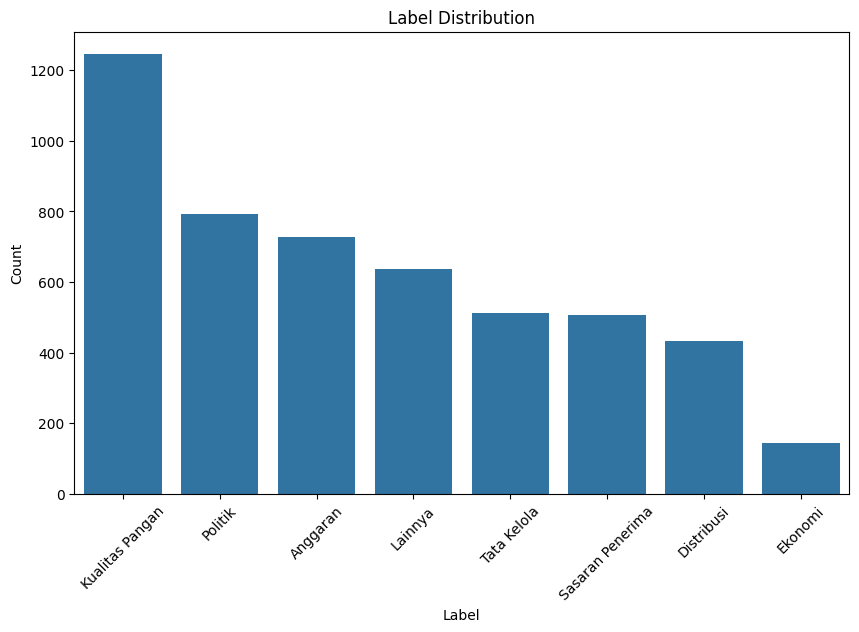

In [12]:
# LABEL DISTRIBUTION

label_counts = train_df['label'].value_counts()

print(label_counts)

plt.figure(figsize=(10,6))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [13]:
# LABEL PERCENTAGE

label_percentage = (
    train_df['label']
    .value_counts(normalize=True) * 100
)

display(label_percentage.round(2))

label
Kualitas Pangan     24.94
Politik             15.84
Anggaran            14.54
Lainnya             12.76
Tata Kelola         10.22
Sasaran Penerima    10.14
Distribusi           8.66
Ekonomi              2.90
Name: proportion, dtype: float64

In [14]:
# TWEET LENGTH ANALYSIS

train_df['tweet_length'] = train_df['full_text'].astype(str).apply(len)

print(train_df['tweet_length'].describe())

count    5000.000000
mean      142.802800
std        87.996681
min         7.000000
25%        73.000000
50%       118.000000
75%       209.000000
max       966.000000
Name: tweet_length, dtype: float64


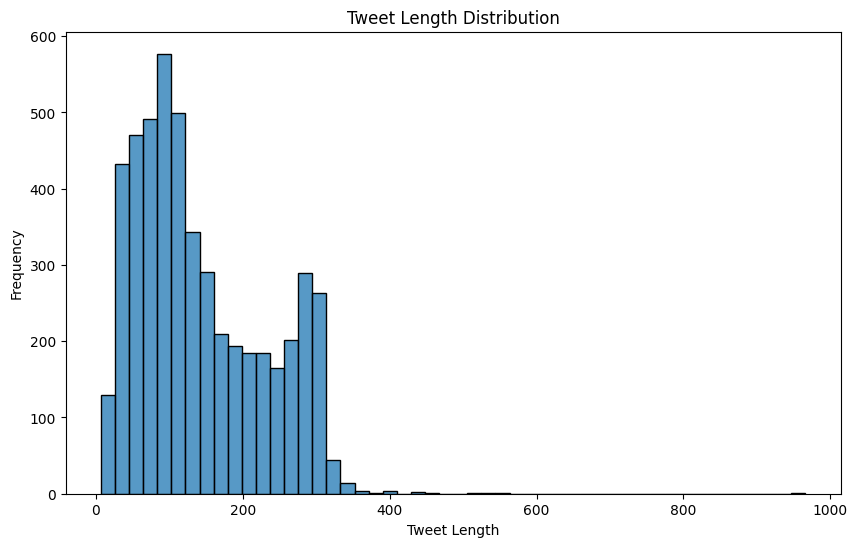

In [15]:
# LENGTH DISTRIBUTION

plt.figure(figsize=(10,6))

sns.histplot(
    train_df['tweet_length'],
    bins=50
)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

In [16]:
# SECTION 11 - BASIC CLEANING FOR ANALYSIS

def basic_cleaning(text):
    
    # ubah ke lowercase
    text = text.lower()
    
    # hapus url
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # hapus mention
    text = re.sub(r'@\w+', '', text)
    
    # hapus hashtag symbol (#)
    text = re.sub(r'#', '', text)
    
    # hapus angka
    text = re.sub(r'\d+', '', text)
    
    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# apply cleaning
train_df['clean_text_analysis'] = train_df['full_text'].astype(str).apply(basic_cleaning)

In [18]:
# SECTION 12 - TOP WORDS PER CLASS

from collections import Counter

TOP_N = 20

for label in train_df['label'].unique():
    
    print(f"TOP WORDS FOR LABEL: {label}")
    
    # ambil semua text berdasarkan label
    texts = train_df[
        train_df['label'] == label
    ]['clean_text_analysis']
    
    # gabungkan semua text
    all_words = ' '.join(texts).split()
    
    # hitung frekuensi kata
    word_counts = Counter(all_words)
    
    # ambil top words
    top_words = word_counts.most_common(TOP_N)
    
    # tampilkan
    for word, count in top_words:
        print(f"{word:<20} : {count}")
    
    print("\n")

TOP WORDS FOR LABEL: Sasaran Penerima
mbg                  : 483
anak                 : 239
program              : 218
makan                : 194
dan                  : 163
bergizi              : 155
gratis               : 145
di                   : 133
untuk                : 112
gizi                 : 110
ini                  : 106
yang                 : 104
juta                 : 90
sekolah              : 88
yg                   : 85
indonesia            : 69
penerima             : 60
itu                  : 53
sehat                : 51
bisa                 : 51


TOP WORDS FOR LABEL: Politik
mbg                  : 759
dan                  : 277
yg                   : 274
program              : 247
di                   : 199
makan                : 171
yang                 : 165
rakyat               : 163
gratis               : 156
prabowo              : 156
ada                  : 155
ini                  : 136
itu                  : 125
aja                  : 105
ga                   